
# Unsupervised Risk Segmentation

## Credit Risk Intelligence Lab

This notebook introduces the first unsupervised learning layer of the project.

The previous notebook built a supervised probability of default model. That model estimates borrower-level risk using a labeled target. This notebook asks a different question: **do hidden borrower groups exist inside the credit portfolio, even before using the default label as a modeling target?**

The objective is to discover borrower segments using transformed credit features, then interpret those segments through observed default rates, predicted probability of default, exposure proxies, and financial characteristics.

In credit risk, segmentation is valuable because two borrowers can have similar estimated probabilities of default but belong to very different risk profiles. A portfolio can also appear diversified at the individual level while being concentrated in a few hidden borrower segments.



## Notebook objectives

This notebook focuses on seven tasks:

1. Load processed borrower features from the feature engineering notebook.
2. Load the baseline probability of default model from the supervised modeling notebook.
3. Use dimensionality reduction to visualize borrower structure.
4. Evaluate different numbers of clusters using unsupervised metrics.
5. Fit a baseline K-Means segmentation model.
6. Profile clusters using observed default rate, predicted PD, exposure, and selected borrower characteristics.
7. Save segment labels, cluster summaries, visualizations, and the trained segmentation model.

The output of this notebook will become the analytical base for anomaly detection and dashboard-level risk reporting.


In [1]:

from pathlib import Path
import warnings
import pickle
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook is designed to run either from the project root or from the `notebooks/` directory.


In [2]:

CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"
REPORTS_TABLES = PROJECT_ROOT / "reports" / "tables"

for path in [DATA_PROCESSED, MODELS_DIR, REPORTS_FIGURES, REPORTS_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data path: {DATA_PROCESSED}")
print(f"Models path: {MODELS_DIR}")
print(f"Figures path: {REPORTS_FIGURES}")
print(f"Tables path: {REPORTS_TABLES}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed
Models path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/models
Figures path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/figures
Tables path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/reports/tables



## Load processed datasets and baseline PD model

This notebook expects the previous notebooks to have generated:

```text
data/processed/X_train_processed.csv
data/processed/X_test_processed.csv
data/processed/y_train.csv
data/processed/y_test.csv
data/processed/X_train.csv
data/processed/X_test.csv
models/baseline_logistic_pd_model.pkl
```

The clustering model will use only the processed feature matrix. The target and predicted PD are used later only to interpret the resulting segments.


In [3]:

required_files = {
    "X_train_processed": DATA_PROCESSED / "X_train_processed.csv",
    "X_test_processed": DATA_PROCESSED / "X_test_processed.csv",
    "y_train": DATA_PROCESSED / "y_train.csv",
    "y_test": DATA_PROCESSED / "y_test.csv",
    "X_train_raw": DATA_PROCESSED / "X_train.csv",
    "X_test_raw": DATA_PROCESSED / "X_test.csv",
    "baseline_pd_model": MODELS_DIR / "baseline_logistic_pd_model.pkl",
}

missing_files = [name for name, path in required_files.items() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Missing files: "
        + ", ".join(missing_files)
        + ". Run notebooks/02_feature_engineering.ipynb and notebooks/03_probability_of_default_model.ipynb before this notebook."
    )

X_train_processed = pd.read_csv(required_files["X_train_processed"], index_col=0)
X_test_processed = pd.read_csv(required_files["X_test_processed"], index_col=0)

y_train = pd.read_csv(required_files["y_train"], index_col=0).iloc[:, 0]
y_test = pd.read_csv(required_files["y_test"], index_col=0).iloc[:, 0]

X_train_raw = pd.read_csv(required_files["X_train_raw"], index_col=0)
X_test_raw = pd.read_csv(required_files["X_test_raw"], index_col=0)

with open(required_files["baseline_pd_model"], "rb") as f:
    baseline_pd_model = pickle.load(f)

print(f"X_train_processed: {X_train_processed.shape}")
print(f"X_test_processed: {X_test_processed.shape}")
print(f"X_train_raw: {X_train_raw.shape}")
print(f"X_test_raw: {X_test_raw.shape}")


X_train_processed: (800, 79)
X_test_processed: (200, 79)
X_train_raw: (800, 29)
X_test_raw: (200, 29)



## Build full segmentation dataset

For portfolio segmentation, we combine train and test observations into one analytical portfolio. This is acceptable because clustering is unsupervised and does not use the target variable during fitting.

However, the target and supervised PD predictions are attached afterward to profile and interpret the clusters.


In [4]:

X_processed = pd.concat([X_train_processed, X_test_processed], axis=0)
X_raw = pd.concat([X_train_raw, X_test_raw], axis=0)
y = pd.concat([y_train, y_test], axis=0)

# Keep a stable row identifier.
X_processed.index = X_processed.index.astype(str)
X_raw.index = X_raw.index.astype(str)
y.index = y.index.astype(str)

# Generate supervised PD for the full portfolio using the model from notebook 03.
predicted_pd = baseline_pd_model.predict_proba(X_processed)[:, 1]

portfolio = X_raw.copy()
portfolio["actual_default"] = y
portfolio["predicted_pd"] = predicted_pd

print(f"Full processed matrix: {X_processed.shape}")
print(f"Full raw portfolio: {portfolio.shape}")

portfolio.head()


Full processed matrix: (1000, 79)
Full raw portfolio: (1000, 31)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,credit_amount_per_month,credit_amount_log,duration_years,long_duration_flag,high_credit_amount_flag,installment_burden_proxy,age_bucket,duration_bucket,credit_amount_bucket,actual_default,predicted_pd
828,A11,36,A32,A41,8335,A65,A75,3,A93,A101,4,A124,47,A143,A153,1,A173,1,A191,A201,231.5278,9.0283,3.0000,1,1,25005,mid_career,long_term,high_amount,1,0.5487
997,A14,12,A32,A43,804,A61,A75,4,A93,A101,4,A123,38,A143,A152,1,A173,1,A191,A201,67.0000,6.6908,1.0000,0,0,3216,mid_career,short_term,low_amount,0,0.1170
148,A11,36,A34,A42,5371,A61,A73,3,A93,A103,2,A122,28,A143,A152,2,A173,1,A191,A201,149.1944,8.5890,3.0000,1,1,16113,early_career,long_term,high_amount,0,0.6783
735,A12,36,A31,A44,3990,A65,A72,3,A92,A101,2,A124,29,A141,A152,1,A171,1,A191,A201,110.8333,8.2918,3.0000,1,1,11970,early_career,long_term,high_amount,0,0.9167
130,A12,48,A32,A40,8487,A65,A74,1,A92,A101,2,A123,24,A143,A152,1,A173,1,A191,A201,176.8125,9.0464,4.0000,1,1,8487,young,very_long_term,high_amount,0,0.5706



## Dimensionality reduction with PCA

The processed feature space contains scaled numerical variables and one-hot encoded categorical variables. This space is useful for modeling, but difficult to visualize directly.

PCA is used here as an exploratory projection. It helps us view borrower structure in two dimensions, but it should not be confused with the full clustering space unless explicitly used for clustering.


In [5]:

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(X_processed)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"],
    index=X_processed.index,
)

pca_explained_variance = pca.explained_variance_ratio_

print(f"PC1 explained variance: {pca_explained_variance[0]:.4f}")
print(f"PC2 explained variance: {pca_explained_variance[1]:.4f}")
print(f"Total explained variance: {pca_explained_variance.sum():.4f}")

pca_df.head()


PC1 explained variance: 0.2571
PC2 explained variance: 0.1139
Total explained variance: 0.3709


,PC1,PC2
828,4.7335,-0.3130
997,-2.4445,-0.7325
148,3.3261,-1.2195
735,2.7763,-1.6196
130,4.5335,-0.9719


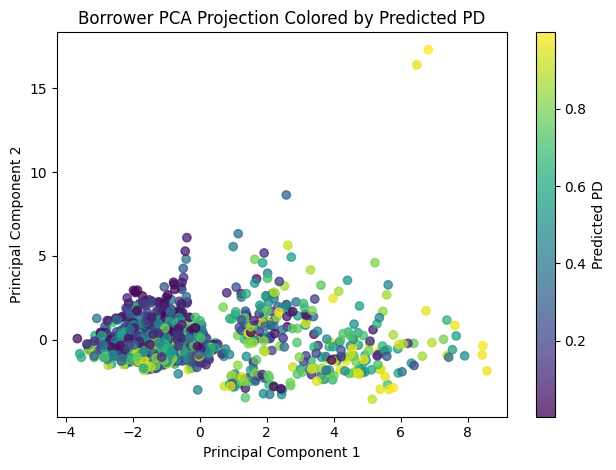

In [6]:

fig, ax = plt.subplots()

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=portfolio["predicted_pd"],
    alpha=0.75,
)

ax.set_title("Borrower PCA Projection Colored by Predicted PD")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

fig.colorbar(scatter, ax=ax, label="Predicted PD")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_pca_projection_by_predicted_pd.png", dpi=150)
plt.show();



## Select number of clusters

There is no single perfect number of clusters. We compare several values of `k` using three unsupervised metrics:

- **Silhouette score**: higher is better.
- **Calinski-Harabasz score**: higher is better.
- **Davies-Bouldin score**: lower is better.

These metrics are not business truth. They are technical guides. The final segmentation should also be interpretable from a credit risk perspective.


In [7]:

cluster_metrics = []

K_RANGE = range(2, 9)

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20,
    )

    labels = kmeans.fit_predict(X_processed)

    cluster_metrics.append(
        {
            "k": k,
            "silhouette_score": silhouette_score(X_processed, labels),
            "calinski_harabasz_score": calinski_harabasz_score(X_processed, labels),
            "davies_bouldin_score": davies_bouldin_score(X_processed, labels),
            "inertia": kmeans.inertia_,
        }
    )

cluster_metrics_df = pd.DataFrame(cluster_metrics)
cluster_metrics_df


,k,silhouette_score,calinski_harabasz_score,davies_bouldin_score,inertia
0,2,0.2322,242.0146,1.8519,"18,486.2964"
1,3,0.2077,168.7015,1.9979,"17,161.4639"
2,4,0.1027,138.6561,2.5679,"16,202.4453"
3,5,0.1046,119.9754,2.1437,"15,495.5218"
4,6,0.0908,107.6562,2.1685,"14,900.2715"
5,7,0.0871,96.7801,2.3311,"14,493.6885"
6,8,0.0863,93.3424,2.1089,"13,848.0041"


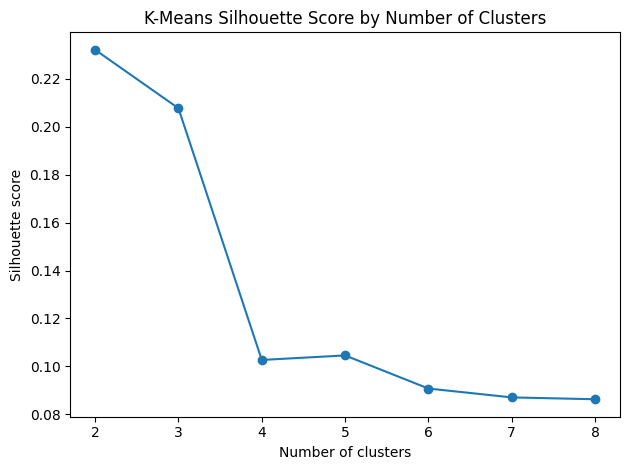

In [8]:

fig, ax = plt.subplots()

ax.plot(cluster_metrics_df["k"], cluster_metrics_df["silhouette_score"], marker="o")

ax.set_title("K-Means Silhouette Score by Number of Clusters")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Silhouette score")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_silhouette_by_k.png", dpi=150)
plt.show();


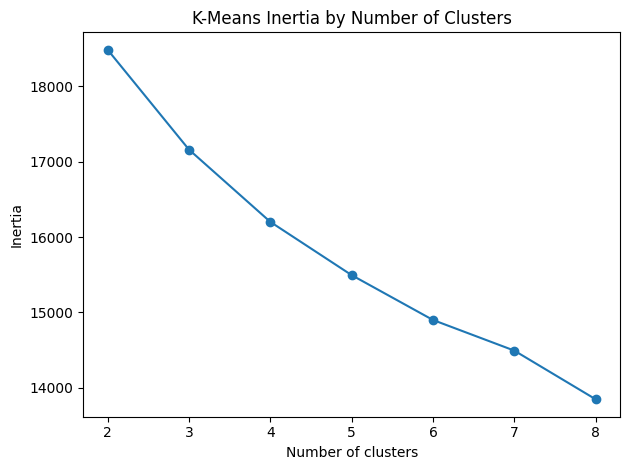

In [9]:

fig, ax = plt.subplots()

ax.plot(cluster_metrics_df["k"], cluster_metrics_df["inertia"], marker="o")

ax.set_title("K-Means Inertia by Number of Clusters")
ax.set_xlabel("Number of clusters")
ax.set_ylabel("Inertia")

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_inertia_by_k.png", dpi=150)
plt.show();



## Fit baseline K-Means segmentation model

For the first segmentation model, we choose the number of clusters that maximizes the silhouette score.

This rule is intentionally simple and reproducible. Later, the project can compare this choice against a business-driven segmentation or a density-based clustering method.


In [10]:

best_k = int(
    cluster_metrics_df
    .sort_values("silhouette_score", ascending=False)
    .iloc[0]["k"]
)

print(f"Selected number of clusters based on silhouette score: {best_k}")

kmeans_model = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=20,
)

cluster_labels = kmeans_model.fit_predict(X_processed)

portfolio["risk_cluster"] = cluster_labels
pca_df["risk_cluster"] = cluster_labels

portfolio["risk_cluster"].value_counts().sort_index()


Selected number of clusters based on silhouette score: 2


risk_cluster
0    718
1    282
Name: count, dtype: int64


## Visualize clusters in PCA space

The chart below projects borrowers into two principal components and colors them by K-Means cluster.

The clustering itself was fitted on the full processed feature space, not only on the two PCA components. Therefore, this chart is a visualization of the segmentation, not the full segmentation logic.


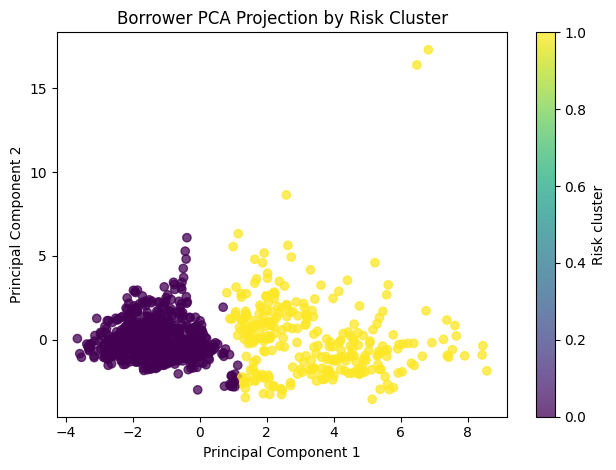

In [11]:

fig, ax = plt.subplots()

scatter = ax.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["risk_cluster"],
    alpha=0.75,
)

ax.set_title("Borrower PCA Projection by Risk Cluster")
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")

fig.colorbar(scatter, ax=ax, label="Risk cluster")
plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_pca_projection_by_cluster.png", dpi=150)
plt.show();



## Cluster-level risk profile

A cluster becomes useful only when it can be interpreted.

We summarize each cluster using:

- Number of borrowers.
- Portfolio share.
- Observed default rate.
- Average predicted PD from the supervised model.
- Average credit amount.
- Total exposure proxy.
- Expected loss proxy using an assumed LGD.


In [12]:

LGD_ASSUMPTION = 0.45

portfolio["ead_proxy"] = portfolio["credit_amount"]
portfolio["expected_loss_proxy"] = (
    portfolio["predicted_pd"]
    * LGD_ASSUMPTION
    * portfolio["ead_proxy"]
)

cluster_risk_summary = (
    portfolio
    .groupby("risk_cluster")
    .agg(
        borrowers=("actual_default", "size"),
        observed_defaults=("actual_default", "sum"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        median_predicted_pd=("predicted_pd", "median"),
        avg_credit_amount=("credit_amount", "mean"),
        total_exposure_proxy=("ead_proxy", "sum"),
        total_expected_loss_proxy=("expected_loss_proxy", "sum"),
        avg_age=("age_years", "mean"),
        avg_duration_months=("duration_months", "mean"),
    )
    .assign(
        portfolio_share=lambda x: x["borrowers"] / len(portfolio),
        exposure_share=lambda x: x["total_exposure_proxy"] / x["total_exposure_proxy"].sum(),
        expected_loss_share=lambda x: x["total_expected_loss_proxy"] / x["total_expected_loss_proxy"].sum(),
    )
    .sort_values("avg_predicted_pd", ascending=False)
)

cluster_risk_summary


,borrowers,observed_defaults,observed_default_rate,avg_predicted_pd,median_predicted_pd,avg_credit_amount,total_exposure_proxy,total_expected_loss_proxy,avg_age,avg_duration_months,portfolio_share,exposure_share,expected_loss_share
risk_cluster,,,,,,,,,,,,,
1,282,120,0.4255,0.5624,0.5901,"6,787.1241",1913969,"508,266.5752",36.1418,33.5461,0.2820,0.5851,0.6936
0,718,180,0.2507,0.3806,0.3341,"1,890.3747",1357289,"224,480.7744",35.3120,15.9373,0.7180,0.4149,0.3064


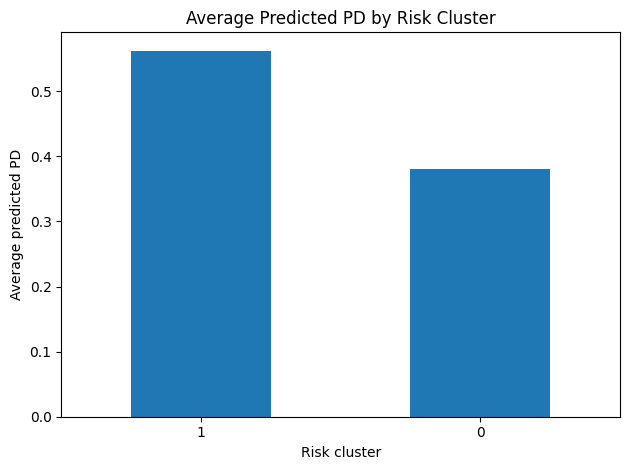

In [13]:

fig, ax = plt.subplots()

cluster_risk_summary["avg_predicted_pd"].plot(kind="bar", ax=ax)

ax.set_title("Average Predicted PD by Risk Cluster")
ax.set_xlabel("Risk cluster")
ax.set_ylabel("Average predicted PD")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_average_pd_by_cluster.png", dpi=150)
plt.show();


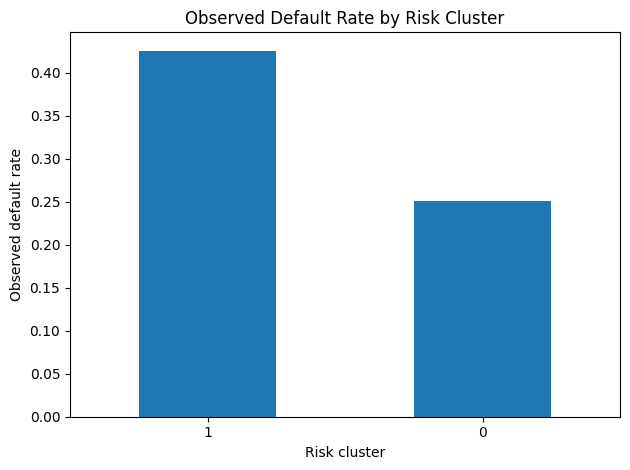

In [14]:

fig, ax = plt.subplots()

cluster_risk_summary["observed_default_rate"].plot(kind="bar", ax=ax)

ax.set_title("Observed Default Rate by Risk Cluster")
ax.set_xlabel("Risk cluster")
ax.set_ylabel("Observed default rate")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(REPORTS_FIGURES / "04_observed_default_rate_by_cluster.png", dpi=150)
plt.show();



## Cluster composition by categorical features

Risk segments should not be described only by model scores. We also need to understand their borrower composition.

This section profiles clusters using selected categorical variables from the raw data.


In [15]:

categorical_profile_features = [
    "checking_account_status",
    "credit_history",
    "purpose",
    "savings_account",
    "employment_since",
    "housing",
    "job",
]

available_categorical_profile_features = [
    col for col in categorical_profile_features if col in portfolio.columns
]

def cluster_category_distribution(data: pd.DataFrame, cluster_col: str, feature: str) -> pd.DataFrame:
    distribution = (
        pd.crosstab(
            data[cluster_col],
            data[feature],
            normalize="index",
        )
        .round(4)
    )
    return distribution

for feature in available_categorical_profile_features:
    print(f"\nCluster composition by {feature}")
    display(cluster_category_distribution(portfolio, "risk_cluster", feature))
    


Cluster composition by checking_account_status


checking_account_status,A11,A12,A13,A14
risk_cluster,,,,
0,0.2786,0.2382,0.0780,0.4053
1,0.2624,0.3475,0.0248,0.3652



Cluster composition by credit_history


credit_history,A30,A31,A32,A33,A34
risk_cluster,,,,,
0,0.0209,0.0474,0.5655,0.0655,0.3008
1,0.0887,0.0532,0.4397,0.1454,0.2730



Cluster composition by purpose


...

employment_since,A71,A72,A73,A74,A75
risk_cluster,,,,,
0,0.0501,0.1894,0.3426,0.1616,0.2563
1,0.0922,0.1277,0.3298,0.2057,0.2447



Cluster composition by housing


housing,A151,A152,A153
risk_cluster,,,
0,0.1964,0.7326,0.0710
1,0.1348,0.6631,0.2021



Cluster composition by job


job,A171,A172,A173,A174
risk_cluster,,,,
0,0.0237,0.2368,0.6462,0.0933
1,0.0177,0.1064,0.5887,0.2872



## Numerical profile by cluster

This section compares clusters across selected numerical variables. The goal is to translate abstract cluster labels into meaningful borrower profiles.


In [16]:

numerical_profile_features = [
    "credit_amount",
    "duration_months",
    "age_years",
    "installment_rate_pct_income",
    "existing_credits",
    "people_liable",
    "credit_amount_per_month",
    "installment_burden_proxy",
]

available_numerical_profile_features = [
    col for col in numerical_profile_features if col in portfolio.columns
]

cluster_numerical_profile = (
    portfolio
    .groupby("risk_cluster")[available_numerical_profile_features]
    .mean()
    .round(4)
)

cluster_numerical_profile


,credit_amount,duration_months,age_years,installment_rate_pct_income,existing_credits,people_liable,credit_amount_per_month,installment_burden_proxy
risk_cluster,,,,,,,,
0,"1,890.3747",15.9373,35.3120,3.0905,1.3872,1.1504,135.9747,"5,544.4373"
1,"6,787.1241",33.5461,36.1418,2.6738,1.4574,1.1667,248.4298,"17,335.5674"



## Cluster interpretation helper

The following table gives a compact description of each cluster based on relative values.

This is an analytical helper, not a final business label. Final labels should be reviewed after inspecting the cluster summaries.


In [17]:

profile_for_labels = cluster_risk_summary.join(
    cluster_numerical_profile,
    rsuffix="_profile",
)

overall_avg_pd = portfolio["predicted_pd"].mean()
overall_default_rate = portfolio["actual_default"].mean()
overall_credit_amount = portfolio["credit_amount"].mean()
overall_duration = portfolio["duration_months"].mean()
overall_age = portfolio["age_years"].mean()

def describe_cluster(row):
    notes = []

    if row["avg_predicted_pd"] >= overall_avg_pd * 1.15:
        notes.append("higher predicted PD")
    elif row["avg_predicted_pd"] <= overall_avg_pd * 0.85:
        notes.append("lower predicted PD")
    else:
        notes.append("near-average predicted PD")

    if row["observed_default_rate"] >= overall_default_rate * 1.15:
        notes.append("higher observed default rate")
    elif row["observed_default_rate"] <= overall_default_rate * 0.85:
        notes.append("lower observed default rate")

    if row["avg_credit_amount"] >= overall_credit_amount * 1.15:
        notes.append("larger average exposure")
    elif row["avg_credit_amount"] <= overall_credit_amount * 0.85:
        notes.append("smaller average exposure")

    if row["avg_duration_months"] >= overall_duration * 1.15:
        notes.append("longer duration")
    elif row["avg_duration_months"] <= overall_duration * 0.85:
        notes.append("shorter duration")

    if row["avg_age"] >= overall_age * 1.10:
        notes.append("older borrowers")
    elif row["avg_age"] <= overall_age * 0.90:
        notes.append("younger borrowers")

    return "; ".join(notes)

cluster_interpretation = cluster_risk_summary.copy()
cluster_interpretation["interpretation_notes"] = cluster_interpretation.apply(describe_cluster, axis=1)

cluster_interpretation[[
    "borrowers",
    "portfolio_share",
    "observed_default_rate",
    "avg_predicted_pd",
    "avg_credit_amount",
    "avg_duration_months",
    "avg_age",
    "interpretation_notes",
]]


,borrowers,portfolio_share,observed_default_rate,avg_predicted_pd,avg_credit_amount,avg_duration_months,avg_age,interpretation_notes
risk_cluster,,,,,,,,
1,282,0.2820,0.4255,0.5624,"6,787.1241",33.5461,36.1418,higher predicted PD; higher observed default r...
0,718,0.7180,0.2507,0.3806,"1,890.3747",15.9373,35.3120,near-average predicted PD; lower observed defa...



## Optional comparison: Agglomerative clustering

K-Means assumes clusters around centroids and tends to favor compact shapes. Agglomerative clustering provides a useful comparison because it builds clusters through hierarchical merging.

This comparison is not meant to replace the baseline segmentation. It simply shows whether a different clustering logic produces materially different risk profiles.


In [18]:

agg_model = AgglomerativeClustering(n_clusters=best_k)
agg_labels = agg_model.fit_predict(X_processed)

portfolio["agg_cluster"] = agg_labels

agg_cluster_summary = (
    portfolio
    .groupby("agg_cluster")
    .agg(
        borrowers=("actual_default", "size"),
        observed_default_rate=("actual_default", "mean"),
        avg_predicted_pd=("predicted_pd", "mean"),
        avg_credit_amount=("credit_amount", "mean"),
        avg_duration_months=("duration_months", "mean"),
        total_exposure_proxy=("ead_proxy", "sum"),
        total_expected_loss_proxy=("expected_loss_proxy", "sum"),
    )
    .assign(
        portfolio_share=lambda x: x["borrowers"] / len(portfolio),
        expected_loss_share=lambda x: x["total_expected_loss_proxy"] / x["total_expected_loss_proxy"].sum(),
    )
    .sort_values("avg_predicted_pd", ascending=False)
)

agg_cluster_summary


,borrowers,observed_default_rate,avg_predicted_pd,avg_credit_amount,avg_duration_months,total_exposure_proxy,total_expected_loss_proxy,portfolio_share,expected_loss_share
agg_cluster,,,,,,,,,
0,299,0.4281,0.5652,"6,532.9064",33.5050,1953339,"518,981.4742",0.2990,0.7083
1,701,0.2454,0.3750,"1,880.0556",15.5278,1317919,"213,765.8755",0.7010,0.2917



## Select final segmentation output

For the project's first unsupervised segmentation layer, we keep the K-Means labels as the baseline `risk_cluster`.

This choice is practical for a first version because K-Means is simple, reproducible, fast, and easy to explain in a GitHub portfolio project. Later versions can compare it with Gaussian Mixture Models, HDBSCAN, or autoencoder-based embeddings.


In [19]:

final_segmentation = portfolio.copy()

final_segmentation_output = final_segmentation[
    [
        "risk_cluster",
        "actual_default",
        "predicted_pd",
        "credit_amount",
        "duration_months",
        "age_years",
        "ead_proxy",
        "expected_loss_proxy",
    ]
].copy()

final_segmentation_output.head()


,risk_cluster,actual_default,predicted_pd,credit_amount,duration_months,age_years,ead_proxy,expected_loss_proxy
828,1,1,0.5487,8335,36,47,8335,"2,058.0017"
997,0,0,0.1170,804,12,38,804,42.3423
148,1,0,0.6783,5371,36,28,5371,"1,639.4020"
735,1,0,0.9167,3990,36,29,3990,"1,645.9621"
130,1,0,0.5706,8487,48,24,8487,"2,179.1908"



## Save segmentation artifacts

This section saves the clustering model, PCA object, cluster assignments, metrics, summaries, and interpretation tables.


In [20]:

with open(MODELS_DIR / "kmeans_risk_segmentation_model.pkl", "wb") as f:
    pickle.dump(kmeans_model, f)

with open(MODELS_DIR / "pca_risk_projection.pkl", "wb") as f:
    pickle.dump(pca, f)

final_segmentation.to_csv(DATA_PROCESSED / "credit_risk_segments.csv", index=True)
final_segmentation_output.to_csv(DATA_PROCESSED / "risk_cluster_assignments.csv", index=True)

cluster_metrics_df.to_csv(REPORTS_TABLES / "04_cluster_selection_metrics.csv", index=False)
cluster_risk_summary.to_csv(REPORTS_TABLES / "04_cluster_risk_summary.csv", index=True)
cluster_numerical_profile.to_csv(REPORTS_TABLES / "04_cluster_numerical_profile.csv", index=True)
cluster_interpretation.to_csv(REPORTS_TABLES / "04_cluster_interpretation.csv", index=True)
agg_cluster_summary.to_csv(REPORTS_TABLES / "04_agglomerative_cluster_summary.csv", index=True)

segmentation_metadata = {
    "model_name": "kmeans_risk_segmentation_model",
    "model_type": "KMeans",
    "selected_k": best_k,
    "selection_rule": "maximum silhouette score over k=2..8",
    "pca_pc1_explained_variance": float(pca_explained_variance[0]),
    "pca_pc2_explained_variance": float(pca_explained_variance[1]),
    "pca_total_2d_explained_variance": float(pca_explained_variance.sum()),
    "lgd_assumption": LGD_ASSUMPTION,
    "n_observations": int(len(final_segmentation)),
    "n_processed_features": int(X_processed.shape[1]),
}

with open(MODELS_DIR / "kmeans_risk_segmentation_metadata.json", "w") as f:
    json.dump(segmentation_metadata, f, indent=4)

print("Saved K-Means model, PCA object, cluster assignments, reports, and metadata.")


Saved K-Means model, PCA object, cluster assignments, reports, and metadata.



## Analytical conclusions

This notebook added the first unsupervised learning component to the Credit Risk Intelligence Lab.

The main analytical contribution is that borrowers are no longer viewed only as individual predictions. They are now organized into hidden portfolio segments that can be compared by default rate, predicted PD, exposure, expected loss proxy, maturity, age, and borrower characteristics.

Key outputs:

- PCA projection of the borrower feature space.
- Cluster selection metrics for K-Means.
- Baseline K-Means risk segmentation.
- Cluster-level risk summaries.
- Numerical and categorical borrower profiles by segment.
- Comparison with agglomerative clustering.
- Saved segment labels and clustering artifacts.

The next notebook should focus on anomaly detection:

```text
notebooks/05_anomaly_detection.ipynb
```

That stage will search for borrowers whose profiles are unusual relative to the rest of the credit portfolio, complementing both the supervised PD model and the unsupervised segment structure.
